### State Schema With DataClasses

When we define a LangGraph StateGraph, we use a state schema.

The state schema represents the structure and types of data that our graph will use.

All nodes are expected to communicate with that schema.

LangGraph offers flexibility in how you define your state schema, accommodating various Python types and validation approaches!


In [1]:
from typing_extensions import TypedDict
from typing import Literal


class TypedDictState(TypedDict):
    name: str
    game: Literal["cricket", "badminton"]

In [2]:
def play_game(state: TypedDictState):
    print("---Play Game node has been called--")
    return {"name": state["name"] + " want to play "}


def cricket(state: TypedDictState):
    print("-- Cricket node has been called--")
    return {"name": state["name"] + " cricket", "game": "cricket"}


def badminton(state: TypedDictState):
    print("-- badminton node has been called--")
    return {"name": state["name"] + " badminton", "game": "badminton"}

In [3]:
import random


def decide_play(state: TypedDictState) -> Literal["cricket", "badminton"]:
    if random.random() < 0.5:
        return "cricket"
    else:
        return "badminton"

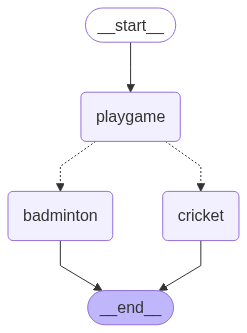

In [4]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

builder = StateGraph(TypedDictState)


builder.add_node("playgame", play_game)
builder.add_node("cricket", cricket)
builder.add_node("badminton", badminton)


builder.add_edge(START, "playgame")
builder.add_conditional_edges("playgame", decide_play)
builder.add_edge("cricket", END)
builder.add_edge("badminton", END)


graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
graph.invoke({"name": "Yash"})

---Play Game node has been called--
-- Cricket node has been called--


{'name': 'Yash want to play  cricket', 'game': 'cricket'}

In [6]:
# graph.invoke({"name": 123})

### Dataclasses

Python's dataclasses provide another way to define structured data.

Dataclasses offer a concise syntax for creating classes that are primarily used to store data.


In [7]:
from dataclasses import dataclass


@dataclass
class DataClassState:
    name: str
    game: Literal["badminton", "cricket"]

In [8]:
def play_game(state: DataClassState):
    print("---Play Game node has been called--")
    return {"name": state.name + " want to play "}


def cricket(state: DataClassState):
    print("-- Cricket node has been called--")
    return {"name": state.name + " cricket", "game": "cricket"}


def badminton(state: DataClassState):
    print("-- badminton node has been called--")
    return {"name": state.name + " badminton", "game": "badminton"}

In [9]:
import random


def decide_play(state: DataClassState) -> Literal["cricket", "badminton"]:
    if random.random() < 0.5:
        return "cricket"
    else:
        return "badminton"

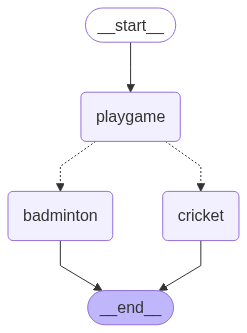

In [10]:
builder = StateGraph(DataClassState)


builder.add_node("playgame", play_game)
builder.add_node("cricket", cricket)
builder.add_node("badminton", badminton)


builder.add_edge(START, "playgame")
builder.add_conditional_edges("playgame", decide_play)
builder.add_edge("cricket", END)
builder.add_edge("badminton", END)


graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
graph.invoke(DataClassState(name="Yash", game="cricket"))

---Play Game node has been called--
-- Cricket node has been called--


{'name': 'Yash want to play  cricket', 'game': 'cricket'}